CALIBRATION DE L'ÉLECTRODE DE RÉFÉRENCE
ΔE/ref initiale (moyenne) = 0.4010 V
E_ref + E_jonction        = 0.2807 V
  (valeur attendue Ag/AgCl ≈ 0.235 V → E_jonction ≈ 0.0 mV)

Nombre de points valides : 72/72
pNH3 : min = 1.83, max = 5.22

Frontière verticale Ag+ / [Ag(NH3)2]+  : pNH3 = 3.70
Potentiel frontière Ag+/Ag (théorique) : E = 0.682 V

FRONTIÈRE 1 : Ag+(aq) / Ag(s)  [pNH3 > 4.0]
  n points         = 23
  pente a          = -0.0023 ± 0.0004 V/pNH3
  E_front1 (exp)   = 0.6936 V  (R² = 0.6028)

FRONTIÈRE 2 : [Ag(NH3)2]+ / Ag(s)  [pNH3 ∈ [2.0, 2.5]]
  n points         = 6
  pente a          = 0.1146 ± 0.0010 V/pNH3
  ordonnée b       = 0.3132 V
  R²               = 0.9997

  Stœchiométrie    x = a·F/(R·T·ln10) = 1.94 ± 0.02
  Score Z (vs 2)   = -3.6  (non compatible avec x=2)

  Intersection (pNH3 Ag+/[Ag(NH3)2]+) = 3.25
  log β[Ag(NH3)2]+ (exp) = 6.51  (ref = 7.4)


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\mnt\\user-data\\outputs\\diagramme_E_pNH3.png'

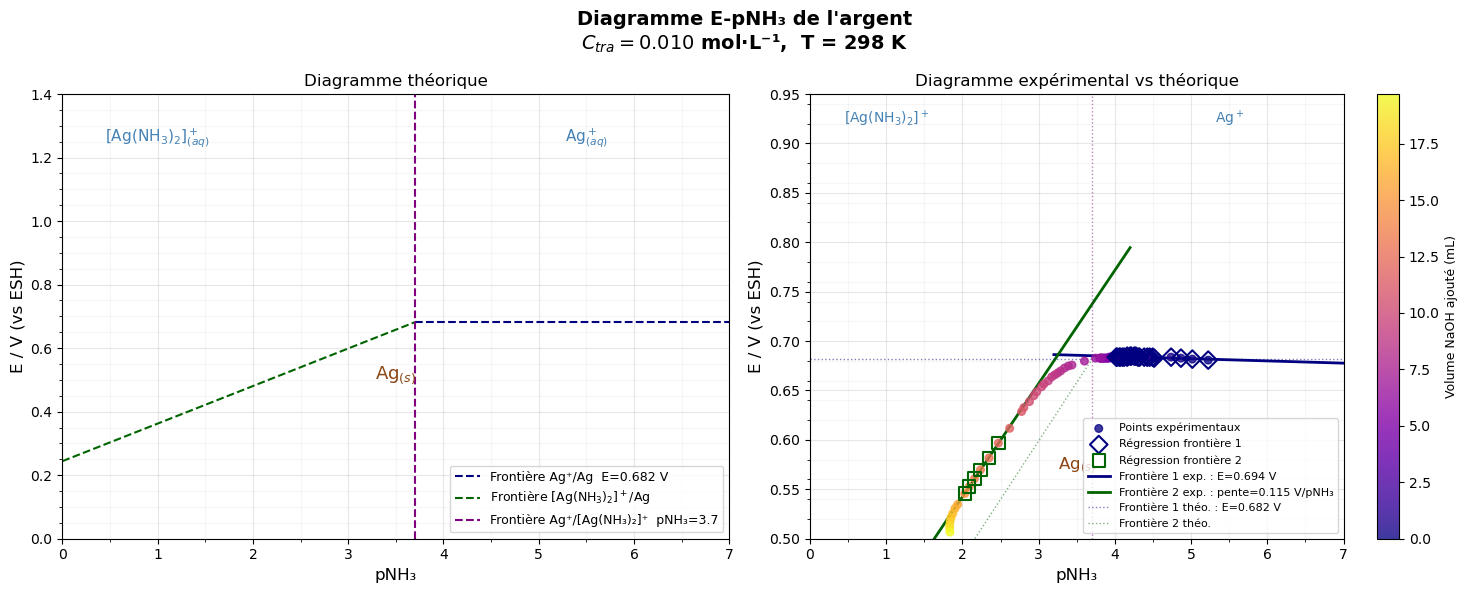

In [1]:
"""
Tracé du diagramme E-pNH3 de l'argent

======================================
À partir de données expérimentales (V_NaOH, pH, ΔE/ref),
ce script calcule pNH3 et E/ESH, puis trace le diagramme
et détermine les paramètres des frontières.

Protocole issu du document : Tracé du diagramme E-pNH3 de l'argent
(Chapitre 6 - Les outils numériques au service de l'électrochimie)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.optimize import brentq
from scipy.stats import linregress

# ─────────────────────────────────────────────────────────────
# 1. CONSTANTES ET DONNÉES THERMODYNAMIQUES (T = 298 K)
# ─────────────────────────────────────────────────────────────
R = 8.314          # J·mol⁻¹·K⁻¹
T = 298.0          # K
F = 96485.0        # C·mol⁻¹
c0 = 1.0           # mol·L⁻¹  (concentration standard)

pKa  = 9.25        # NH4+/NH3
Ka   = 10**(-pKa)

E0_Ag = 0.80       # V  E°(Ag+/Ag) / ESH

log_beta1 = 3.4    # log β[Ag(NH3)]+
log_beta2 = 7.4    # log β[Ag(NH3)2]+
beta1 = 10**log_beta1
beta2 = 10**log_beta2

RT_F = R * T / F   # ≈ 0.02569 V  (facteur de Nernst)

# ─────────────────────────────────────────────────────────────
# 2. PARAMÈTRES EXPÉRIMENTAUX
# ─────────────────────────────────────────────────────────────
V0      = 50.0e-3  # L   volume initial de solution Ag+/NH4+
C_Ag0   = 1.0e-2   # mol·L⁻¹   concentration initiale en Ag+
C_NH4_0 = 4.0e-2   # mol·L⁻¹   concentration initiale en NH4+
C_NaOH  = 0.10     # mol·L⁻¹   concentration de la soude (burette automatique)
C_NaOH_dil = 0.020 # mol·L⁻¹   soude diluée (premiers points)

# ─────────────────────────────────────────────────────────────
# 3. DONNÉES EXPÉRIMENTALES (à remplacer par vos mesures réelles)
#
#    Format : tableau numpy de colonnes [V_mL, pH, DeltaE_ref_V]
#    V_mL     : volume de soude ajouté (mL)
#    pH        : pH mesuré par le pH-mètre
#    DeltaE_ref: différence de potentiel mesurée (V) vs électrode Ag/AgCl
#
#    Les données ci-dessous sont des données SIMULÉES à titre d'exemple.
#    Remplacez-les par vos données expérimentales réelles.
# ─────────────────────────────────────────────────────────────

np.random.seed(42)

def simulate_experiment():
    """
    Simule des données expérimentales réalistes.
    Remplacez cette fonction par vos données réelles !
    """
    # Volumes de soude versés (mL) - premiers points avec soude diluée,
    # puis soude concentrée
    V_list = np.concatenate([
        np.linspace(0.1, 5.0, 25),   # soude 0.020 mol/L (5 mL)
        np.linspace(5.5, 20.0, 30),  # soude 0.10  mol/L (20 mL)
    ])

    pH_list   = []
    dE_list   = []

    n_Ag0   = C_Ag0  * V0       # mol Ag+  initial
    n_NH4_0 = C_NH4_0 * V0      # mol NH4+ initial
    E_ref_calibrated = 0.239    # V (calibré expérimentalement, éq. 6.8)

    for V_mL in V_list:
        V = V_mL * 1e-3          # L
        V_tot = V0 + V

        # Concentration totale en Ag (conservation matière)
        C_Ag_tot = n_Ag0 / V_tot

        # pH simulé (montée progressive de 4.5 à 11)
        pH_sim = 4.5 + 6.5 * (1 - np.exp(-V_mL / 8))
        pH_sim += np.random.normal(0, 0.02)
        pH = max(4.0, min(11.5, pH_sim))

        H_conc = 10**(-pH)

        # Concentration en NH4+ via Ka
        # Concentration totale azote conservée (NH4+ + NH3 + complexes ~ n_NH4_0/V_tot)
        C_N_tot = n_NH4_0 / V_tot  # approximation (sans complexes pour le pH seul)

        # [NH3] via Ka : [NH4+]/[NH3] = [H+]/Ka
        alpha_NH3 = Ka / (H_conc + Ka)
        NH3_approx = alpha_NH3 * C_N_tot  # première estimation

        # Potentiel de Nernst simulé pour [Ag+] effectif
        # Au début : Ag+ libre domine (pNH3 élevé), puis complexe domine (pNH3 faible)
        NH3 = max(NH3_approx, 1e-12)
        denom = 1 + beta1 * NH3 / c0 + beta2 * (NH3 / c0)**2
        Ag_free = C_Ag_tot / denom

        E_ESH = E0_Ag + RT_F * np.log(max(Ag_free / c0, 1e-15))
        # On en déduit ΔE/ref = E_ESH - E_ref_calibrated
        dE = E_ESH - E_ref_calibrated + np.random.normal(0, 0.003)

        pH_list.append(pH)
        dE_list.append(dE)

    return V_list, np.array(pH_list), np.array(dE_list)


# ── Chargement des données ──────────────────────────────────
# Option A : données simulées (exemple)
#V_mL_arr, pH_arr, dE_arr = simulate_experiment()

# Option B : chargez vos données réelles depuis un fichier CSV
import pandas as pd
df = pd.read_csv("mes_donnees.csv")   # colonnes : V_mL, pH, DeltaE
V_mL_arr = df["V_mL"].values
pH_arr   = df["pH"].values
dE_arr   = df["DeltaE"].values*0.001
def fix_french_float(arr):
    return np.array([float(str(x).replace(',', '.')) for x in arr])

V_mL_arr  = fix_french_float(V_mL_arr)
pH_arr    = fix_french_float(pH_arr)
dE_arr = fix_french_float(dE_arr)

# ─────────────────────────────────────────────────────────────
# 4. CALIBRATION DE L'ÉLECTRODE DE RÉFÉRENCE (éq. 6.8)
# ─────────────────────────────────────────────────────────────
#   E_ref + E_jonction = E°(Ag+/Ag) + (RT/F)·ln([Ag+]_init/c°) − ΔE/ref_init
#   On utilise les premiers points où [Ag+] ≈ C_Ag0 (avant toute complexation)

n_calib = 3   # nombre de premiers points pour la calibration
[Ag_init] = [C_Ag0]  # concentration initiale connue

dE_ref_init_mean = np.mean(dE_arr[:n_calib])
E_ref_plus_Ejunction = (E0_Ag
                        + RT_F * np.log(C_Ag0 / c0)
                        - dE_ref_init_mean)

print("=" * 60)
print("CALIBRATION DE L'ÉLECTRODE DE RÉFÉRENCE")
print("=" * 60)
print(f"ΔE/ref initiale (moyenne) = {dE_ref_init_mean:.4f} V")
print(f"E_ref + E_jonction        = {E_ref_plus_Ejunction:.4f} V")
print(f"  (valeur attendue Ag/AgCl ≈ 0.235 V → E_jonction ≈ "
      f"{E_ref_plus_Ejunction - 0.235:.1f} mV)")

# ─────────────────────────────────────────────────────────────
# 5. CALCUL DE E/ESH  (éq. 6.9)
# ─────────────────────────────────────────────────────────────
E_ESH_arr = dE_arr + E_ref_plus_Ejunction

# ─────────────────────────────────────────────────────────────
# 6. CALCUL DE [NH3] ET pNH3  (éq. 6.16 → 6.19)
# ─────────────────────────────────────────────────────────────

def compute_NH3(V_mL, pH, E_ESH, V0=V0, C_Ag0=C_Ag0, C_NH4_0=C_NH4_0):
    """
    Calcule [NH3] à partir du pH et de E/ESH mesurés (éq. 6.19).
    Retourne [NH3] en mol·L⁻¹ et pNH3.
    """
    V   = V_mL * 1e-3
    V_tot = V0 + V

    n_Ag0   = C_Ag0  * V0
    n_NH4_0 = C_NH4_0 * V0

    # [Ag+] via Nernst (éq. 6.18)
    Ag_free = c0 * np.exp((E_ESH - E0_Ag) * F / (R * T))

    # Numérateur de l'éq. 6.19
    numerateur = (n_NH4_0 / V_tot
                  - 2 * n_Ag0 / V_tot
                  + 2 * c0 * np.exp((E_ESH - E0_Ag) * F / (R * T)))

    # Dénominateur de l'éq. 6.19
    H_conc = 10**(-pH)
    denominateur = 1 + H_conc / Ka - beta1 * Ag_free / c0

    if denominateur <= 0 or numerateur < 0:
        return np.nan, np.nan

    NH3 = numerateur / denominateur
    if NH3 <= 0:
        return np.nan, np.nan

    pNH3 = -np.log10(NH3 / c0)
    return NH3, pNH3


pNH3_arr = np.array([
    compute_NH3(v, ph, e)[1]
    for v, ph, e in zip(V_mL_arr, pH_arr, E_ESH_arr)
])

# Filtrage des valeurs invalides
mask_valid = np.isfinite(pNH3_arr) & np.isfinite(E_ESH_arr)
pNH3_valid = pNH3_arr[mask_valid]
E_valid    = E_ESH_arr[mask_valid]
V_valid    = V_mL_arr[mask_valid]

print(f"\nNombre de points valides : {mask_valid.sum()}/{len(mask_valid)}")
print(f"pNH3 : min = {pNH3_valid.min():.2f}, max = {pNH3_valid.max():.2f}")

# ─────────────────────────────────────────────────────────────
# 7. DIAGRAMME E-pNH3 THÉORIQUE (frontières)
# ─────────────────────────────────────────────────────────────

Ctra = C_Ag0  # concentration de tracé (mol·L⁻¹)

pNH3_theory = np.linspace(0, 7, 300)
NH3_theory  = c0 * 10**(-pNH3_theory)

# -- Frontière 1 : Ag+(aq) / Ag(s)  (horizontale, éq. Nernst à [Ag+]=Ctra) --
E_front1_theory = E0_Ag + RT_F * np.log(Ctra / c0)
E_f1_line = np.full_like(pNH3_theory, E_front1_theory)

# -- Frontière 2 : [Ag(NH3)2]+(aq) / Ag(s)  (oblique, éq. 6.20-6.21 avec x=2) --
#    E = E°(Ag(NH3)2+/Ag) + (RT/F)*ln([Ag(NH3)2+]*c°/(NH3)²)
#    À la frontière : [[Ag(NH3)2+] = Ctra
x = 2
E0_complex2_Ag = E0_Ag - RT_F * np.log(beta2)  # potentiel standard apparent
E_f2_line = (E0_complex2_Ag
             + x * RT_F * np.log(10) * pNH3_theory
             + RT_F * np.log(Ctra / c0))

# -- Frontière verticale : Ag+(aq) / [Ag(NH3)2]+(aq)  --
#    À cette frontière : [Ag+] = [Ag(NH3)2+] = Ctra
#    β2 = [Ag(NH3)2+]*c°² / ([Ag+]*[NH3]²) →  [NH3]² = c°²/β2  → pNH3 = log(β2)/2
pNH3_front_vert = log_beta2 / 2
print(f"\nFrontière verticale Ag+ / [Ag(NH3)2]+  : pNH3 = {pNH3_front_vert:.2f}")
print(f"Potentiel frontière Ag+/Ag (théorique) : E = {E_front1_theory:.3f} V")

# ─────────────────────────────────────────────────────────────
# 8. RÉGRESSIONS LINÉAIRES SUR LES FRONTIÈRES EXPÉRIMENTALES
# ─────────────────────────────────────────────────────────────

# -- Frontière 1 : Ag+(aq)/Ag(s) → zone de pNH3 élevé (peu de complexe)
#    On sélectionne les points avec pNH3 > pNH3_front_vert + 0.3
mask_f1 = pNH3_valid > (pNH3_front_vert + 0.3)
if mask_f1.sum() >= 3:
    slope_f1, intercept_f1, r_f1, p_f1, se_f1 = linregress(
        pNH3_valid[mask_f1], E_valid[mask_f1])
    E_front1_exp = intercept_f1   # modèle constant → ordonnée à l'origine ≈ E_front1
    print(f"\nFRONTIÈRE 1 : Ag+(aq) / Ag(s)  [pNH3 > {pNH3_front_vert + 0.3:.1f}]")
    print(f"  n points         = {mask_f1.sum()}")
    print(f"  pente a          = {slope_f1:.4f} ± {se_f1:.4f} V/pNH3")
    print(f"  E_front1 (exp)   = {intercept_f1:.4f} V  (R² = {r_f1**2:.4f})")
else:
    slope_f1, intercept_f1 = 0, E_front1_theory
    print("\n⚠  Pas assez de points pour régresser la frontière 1")

# -- Frontière 2 : [Ag(NH3)2]+(aq)/Ag(s) → zone de pNH3 moyen (2 à 2.5)
mask_f2 = (pNH3_valid >= 2.0) & (pNH3_valid <= 2.5)
if mask_f2.sum() >= 3:
    slope_f2, intercept_f2, r_f2, p_f2, se_f2 = linregress(
        pNH3_valid[mask_f2], E_valid[mask_f2])

    x_exp = slope_f2 * F / (R * T * np.log(10))
    # Incertitude sur x via propagation
    se_x = se_f2 * F / (R * T * np.log(10))

    print(f"\nFRONTIÈRE 2 : [Ag(NH3)2]+ / Ag(s)  [pNH3 ∈ [2.0, 2.5]]")
    print(f"  n points         = {mask_f2.sum()}")
    print(f"  pente a          = {slope_f2:.4f} ± {se_f2:.4f} V/pNH3")
    print(f"  ordonnée b       = {intercept_f2:.4f} V")
    print(f"  R²               = {r_f2**2:.4f}")
    print(f"\n  Stœchiométrie    x = a·F/(R·T·ln10) = {x_exp:.2f} ± {se_x:.2f}")
    score_Z = (x_exp - 2.0) / se_x
    print(f"  Score Z (vs 2)   = {score_Z:.1f}  "
          f"({'compatible' if abs(score_Z) <= 2 else 'non compatible'} avec x=2)")

    # Intersection des deux frontières → pNH3 de séparation Ag+/[Ag(NH3)2]+
    # E_f1 = slope_f1*p + intercept_f1  et  E_f2 = slope_f2*p + intercept_f2
    if abs(slope_f2 - slope_f1) > 1e-6:
        pNH3_intersection = (intercept_f1 - intercept_f2) / (slope_f2 - slope_f1)
        print(f"\n  Intersection (pNH3 Ag+/[Ag(NH3)2]+) = {pNH3_intersection:.2f}")

    # Constante de formation via éq. 6.22
    # β2 = 1 / 10^(-2·pNH3_intersection)
    log_beta2_exp = 2 * pNH3_intersection if 'pNH3_intersection' in dir() else log_beta2
    print(f"  log β[Ag(NH3)2]+ (exp) = {log_beta2_exp:.2f}  "
          f"(ref = {log_beta2})")
else:
    slope_f2, intercept_f2 = RT_F * np.log(10) * 2, 0
    print("\n⚠  Pas assez de points pour régresser la frontière 2")

# ─────────────────────────────────────────────────────────────
# 9. TRACÉ DU DIAGRAMME
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Diagramme E-pNH₃ de l'argent\n"
             f"$C_{{tra}} = {Ctra:.3f}$ mol·L⁻¹,  T = {T:.0f} K",
             fontsize=14, fontweight='bold')

# ─── Axe gauche : diagramme théorique ───────────────────────
ax1 = axes[0]
ax1.set_title("Diagramme théorique", fontsize=12)

# Domaines (texte)
ax1.text(1.0, 1.25, r"$[\mathrm{Ag(NH_3)_2}]^+_{(aq)}$",
         fontsize=11, ha='center', color='steelblue')
ax1.text(5.5, 1.25, r"$\mathrm{Ag}^+_{(aq)}$",
         fontsize=11, ha='center', color='steelblue')
ax1.text(3.5, 0.50, r"$\mathrm{Ag}_{(s)}$",
         fontsize=13, ha='center', color='saddlebrown')

# Frontières théoriques
pNH3_f1_range = np.linspace(pNH3_front_vert, 7, 100)
ax1.axhline(E_front1_theory,
            xmin=(pNH3_front_vert / 7), color='navy',
            linewidth=1.5, linestyle='--', label=f'Frontière Ag⁺/Ag  E={E_front1_theory:.3f} V')

pNH3_f2_range = np.linspace(0, pNH3_front_vert, 100)
E_f2_range = (E0_complex2_Ag
              + 2 * RT_F * np.log(10) * pNH3_f2_range
              + RT_F * np.log(Ctra / c0))
ax1.plot(pNH3_f2_range, E_f2_range,
         color='darkgreen', linewidth=1.5, linestyle='--',
         label=r'Frontière $[\mathrm{Ag(NH_3)_2}]^+$/Ag')

# Frontière verticale
ax1.axvline(pNH3_front_vert, color='purple',
            linewidth=1.5, linestyle='--',
            label=f'Frontière Ag⁺/[Ag(NH₃)₂]⁺  pNH₃={pNH3_front_vert:.1f}')

ax1.set_xlabel("pNH₃", fontsize=12)
ax1.set_ylabel("E / V (vs ESH)", fontsize=12)
ax1.set_xlim(0, 7)
ax1.set_ylim(0.0, 1.40)
ax1.legend(fontsize=9, loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
ax1.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
ax1.grid(True, which='minor', alpha=0.1)

# ─── Axe droit : diagramme expérimental ─────────────────────
ax2 = axes[1]
ax2.set_title("Diagramme expérimental vs théorique", fontsize=12)

# Points expérimentaux
sc = ax2.scatter(pNH3_valid, E_valid, c=V_valid,
                 cmap='plasma', s=30, zorder=5,
                 label='Points expérimentaux', alpha=0.8)
cbar = fig.colorbar(sc, ax=ax2)
cbar.set_label("Volume NaOH ajouté (mL)", fontsize=9)

# Points utilisés pour la régression (en gras)
if mask_f1.sum() >= 3:
    ax2.scatter(pNH3_valid[mask_f1], E_valid[mask_f1],
                s=80, marker='D', facecolors='none', edgecolors='navy',
                linewidths=1.5, zorder=6, label='Régression frontière 1')
if mask_f2.sum() >= 3:
    ax2.scatter(pNH3_valid[mask_f2], E_valid[mask_f2],
                s=80, marker='s', facecolors='none', edgecolors='darkgreen',
                linewidths=1.5, zorder=6, label='Régression frontière 2')

# Régressions linéaires
p_range = np.linspace(pNH3_front_vert - 0.5, 7.0, 100)
if mask_f1.sum() >= 3:
    ax2.plot(p_range, slope_f1 * p_range + intercept_f1,
             color='navy', linewidth=2, label=f'Frontière 1 exp. : E={intercept_f1:.3f} V')

if mask_f2.sum() >= 3:
    p_range2 = np.linspace(1.5, pNH3_front_vert + 0.5, 100)
    ax2.plot(p_range2, slope_f2 * p_range2 + intercept_f2,
             color='darkgreen', linewidth=2,
             label=f'Frontière 2 exp. : pente={slope_f2:.3f} V/pNH₃')

# Frontières théoriques (pointillés)
ax2.axhline(E_front1_theory, color='navy', linewidth=1, linestyle=':',
            alpha=0.5, label=f'Frontière 1 théo. : E={E_front1_theory:.3f} V')
E_f2_range2 = (E0_complex2_Ag
               + 2 * RT_F * np.log(10) * pNH3_f2_range
               + RT_F * np.log(Ctra / c0))
ax2.plot(pNH3_f2_range, E_f2_range2, color='darkgreen',
         linewidth=1, linestyle=':', alpha=0.5, label='Frontière 2 théo.')
ax2.axvline(pNH3_front_vert, color='purple', linewidth=1, linestyle=':',
            alpha=0.5)

# Domaines (texte)
ax2.text(1.0, 0.92, r"$[\mathrm{Ag(NH_3)_2}]^+$",
         fontsize=10, ha='center', color='steelblue')
ax2.text(5.5, 0.92, r"$\mathrm{Ag}^+$",
         fontsize=10, ha='center', color='steelblue')
ax2.text(3.5, 0.57, r"$\mathrm{Ag}_{(s)}$",
         fontsize=12, ha='center', color='saddlebrown')

ax2.set_xlabel("pNH₃", fontsize=12)
ax2.set_ylabel("E / V (vs ESH)", fontsize=12)
ax2.set_xlim(0, 7)
ax2.set_ylim(0.50, 0.95)
ax2.legend(fontsize=8, loc='lower right')
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
ax2.yaxis.set_minor_locator(ticker.MultipleLocator(0.02))
ax2.grid(True, which='minor', alpha=0.1)

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/diagramme_E_pNH3.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Figure sauvegardée : diagramme_E_pNH3.png")

# ─────────────────────────────────────────────────────────────
# 10. RÉSUMÉ FINAL
# ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("RÉSUMÉ DES RÉSULTATS")
print("=" * 60)
print(f"{'Paramètre':<45} {'Exp.':>10} {'Théo.':>10}")
print("-" * 65)
print(f"{'E frontière 1  Ag+(aq)/Ag(s) [V]':<45} "
      f"{intercept_f1:>10.3f} {E_front1_theory:>10.3f}")
if mask_f2.sum() >= 3:
    print(f"{'Pente frontière 2  [Ag(NH3)2]+/Ag [V/pNH3]':<45} "
          f"{slope_f2:>10.4f} {2*RT_F*np.log(10):>10.4f}")
    print(f"{'Stœchiométrie x du complexe':<45} "
          f"{x_exp:>10.2f} {'2.00':>10}")
    print(f"{'log β[Ag(NH3)2]+ ':<45} "
          f"{log_beta2_exp:>10.2f} {log_beta2:>10.2f}")
print("=" * 60)

In [15]:
pH_arr

array([ 5.43,  5.63,  5.77,  5.89,  6.12,  6.13,  6.17,  6.2 ,  6.24,
        6.3 ,  6.32,  6.34,  6.36,  6.4 ,  6.41,  6.45,  6.46,  6.5 ,
        6.52,  6.55,  6.56,  6.59,  6.6 ,  6.62,  6.64,  6.66,  6.66,
        6.67,  6.69,  6.7 ,  6.72,  6.73,  6.75,  6.76,  6.78,  6.79,
        6.79,  6.81,  6.81,  6.82,  6.87,  7.03,  7.21,  7.26,  7.32,
        7.39,  7.44,  7.49,  7.54,  7.61,  7.68,  7.73,  7.82,  7.88,
        7.97,  8.07,  8.12,  8.35,  8.56,  8.75,  8.93,  9.07,  9.21,
        9.35,  9.64,  9.8 ,  9.99, 10.21, 10.44, 10.7 , 10.88, 11.18])

In [16]:
dE_arr

array([0.4  , 0.401, 0.402, 0.403, 0.402, 0.403, 0.403, 0.403, 0.403,
       0.403, 0.403, 0.404, 0.404, 0.404, 0.404, 0.404, 0.403, 0.403,
       0.403, 0.403, 0.403, 0.403, 0.403, 0.403, 0.403, 0.403, 0.403,
       0.403, 0.403, 0.402, 0.402, 0.402, 0.402, 0.402, 0.402, 0.402,
       0.402, 0.402, 0.402, 0.402, 0.402, 0.399, 0.395, 0.394, 0.392,
       0.389, 0.387, 0.385, 0.383, 0.379, 0.376, 0.373, 0.368, 0.364,
       0.358, 0.352, 0.348, 0.331, 0.316, 0.301, 0.289, 0.28 , 0.272,
       0.265, 0.254, 0.25 , 0.245, 0.241, 0.237, 0.233, 0.23 , 0.226])

In [8]:
V_mL_arr

array([ 0. ,  0.2,  0.3,  0.5,  0.8,  0.9,  1.1,  1.2,  1.3,  1.5,  1.7,
        1.8,  1.9,  2. ,  2.1,  2.3,  2.4,  2.7,  2.8,  3.1,  3.2,  3.4,
        3.6,  3.7,  4. ,  4.1,  4.2,  4.3,  4.5,  4.7,  4.8,  5. ,  5.2,
        5.3,  5.5,  5.6,  5.8,  6. ,  6.2,  6.3,  6.6,  7.1,  7.6,  7.8,
        8. ,  8.3,  8.5,  8.7,  8.9,  9.1,  9.5,  9.7, 10. , 10.2, 10.5,
       10.9, 11.1, 11.7, 12.2, 12.7, 13.3, 13.7, 14.2, 14.7, 15.7, 16.2,
       16.7, 17.2, 17.7, 18.2, 18.7, 19.7])